# Import, chargement, estimation de sigma

>>> Upload bnp_data.xlsx :


Saving bnp_data.xlsx to bnp_data.xlsx

Période  : 2025-05-05 → 2026-04-30
Séances  : 254
Cours min/max : 65.34 / 96.37 EUR
Cours au dernier jour : 89.23 EUR

Close-to-close  : 27.39%   IC95 [25.0%, 29.8%]
EWMA (λ=0.94)   : 32.91%
Parkinson (HL)  : 22.52%
Garman-Klass    : 22.56%

Médiane des 4   : 24.97%
>>> σ retenue pour le pricer = 25%


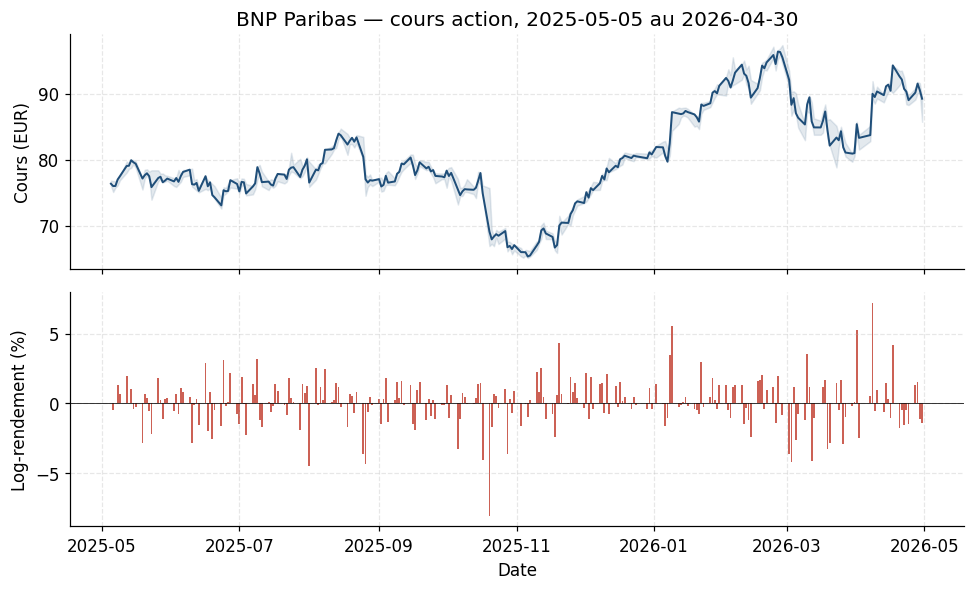

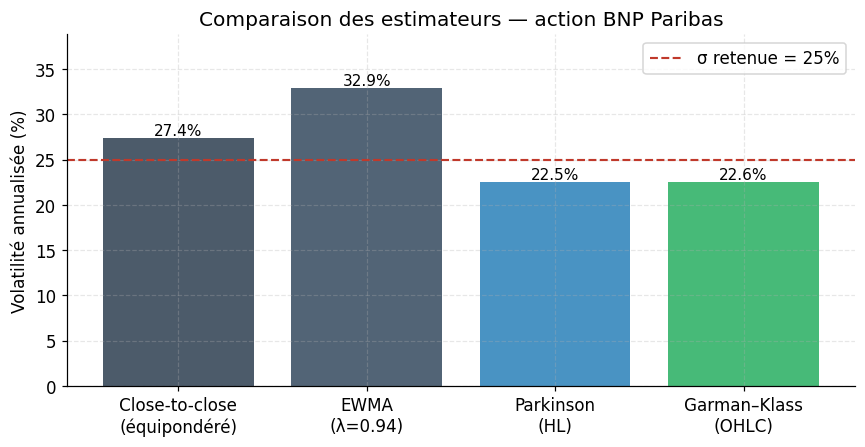

In [ ]:
# ============================================================
# CELLULE 1 — Chargement données action BNP + estimation σ
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from google.colab import files

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
})

# --- Upload ---
print(">>> Upload bnp_data.xlsx :")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

# --- Nettoyage ---
def parse_date(x):
    if isinstance(x, str):
        return pd.to_datetime(x, format="%d/%m/%Y", errors="coerce")
    return pd.to_datetime(x)

def to_float(x):
    if isinstance(x, str):
        return float(x.replace(",", ".").replace(" ", "")
                      .replace("BP", "").replace("%", ""))
    return float(x)

df = pd.read_excel(fname)
df["Date"]  = df["Date"].apply(parse_date)
df["close"] = df["Dernier"].apply(to_float)
df["high"]  = df["+ haut"].apply(to_float)
df["low"]   = df["+ bas"].apply(to_float)
df["open"]  = df["Ouverture"].apply(to_float)
df = df.sort_values("Date").reset_index(drop=True)

print(f"\nPériode  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Séances  : {len(df)}")
print(f"Cours min/max : {df['close'].min():.2f} / {df['close'].max():.2f} EUR")
print(f"Cours au dernier jour : {df['close'].iloc[-1]:.2f} EUR")

# --- Log-rendements ---
df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
ret = df["log_ret"].dropna().values
n   = len(ret)

# ---- Estimateur 1 : close-to-close (équipondéré) ----
sigma_c2c = ret.std(ddof=1) * np.sqrt(252)
se_c2c    = sigma_c2c / np.sqrt(2*(n-1))
ci95      = (sigma_c2c - 1.96*se_c2c, sigma_c2c + 1.96*se_c2c)

# ---- Estimateur 2 : EWMA (RiskMetrics λ=0.94) ----
lam = 0.94
w   = (1-lam) * lam**np.arange(n-1, -1, -1); w /= w.sum()
sigma_ewma = np.sqrt(np.sum(w * (ret - np.sum(w*ret))**2) * 252)

# ---- Estimateur 3 : Parkinson (1980) — exploite High/Low ----
ln_hl      = np.log(df["high"] / df["low"]).dropna().values
sigma_park = np.sqrt(np.mean(ln_hl**2) / (4*np.log(2))) * np.sqrt(252)

# ---- Estimateur 4 : Garman-Klass (1980) — exploite OHLC ----
ln_co    = np.log(df["close"] / df["open"]).dropna().values
ln_hl_gk = ln_hl[:len(ln_co)]
gk       = 0.5*ln_hl_gk**2 - (2*np.log(2)-1)*ln_co**2
sigma_gk = np.sqrt(np.mean(gk) * 252)

# ---- Synthèse ----
print("\n" + "="*55)
print(f"Close-to-close  : {sigma_c2c*100:.2f}%   IC95 [{ci95[0]*100:.1f}%, {ci95[1]*100:.1f}%]")
print(f"EWMA (λ=0.94)   : {sigma_ewma*100:.2f}%")
print(f"Parkinson (HL)  : {sigma_park*100:.2f}%")
print(f"Garman-Klass    : {sigma_gk*100:.2f}%")

SIGMA_RETENUE  = float(np.median([sigma_c2c, sigma_ewma, sigma_park, sigma_gk]))
SIGMA_ARRONDIE = round(SIGMA_RETENUE, 2)
print(f"\nMédiane des 4   : {SIGMA_RETENUE*100:.2f}%")
print(f">>> σ retenue pour le pricer = {SIGMA_ARRONDIE*100:.0f}%")
print("="*55)

# ---- Figure 1 : cours + log-rendements ----
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(df["Date"], df["close"], color="#1f4e79", lw=1.3)
axes[0].fill_between(df["Date"], df["low"], df["high"],
                     color="#1f4e79", alpha=0.12)
axes[0].set_ylabel("Cours (EUR)")
axes[0].set_title(f"BNP Paribas — cours action, "
                  f"{df['Date'].min().date()} au {df['Date'].max().date()}")
axes[1].bar(df["Date"], df["log_ret"]*100,
            color="#c0392b", alpha=0.8, width=0.8)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel("Log-rendement (%)")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("fig_42_cours_returns.pdf", bbox_inches="tight")
plt.show()

# ---- Figure 2 : comparaison des 4 estimateurs ----
fig, ax = plt.subplots(figsize=(8, 4.2))
labels = ["Close-to-close\n(équipondéré)", "EWMA\n(λ=0.94)",
          "Parkinson\n(HL)", "Garman–Klass\n(OHLC)"]
vals   = [sigma_c2c*100, sigma_ewma*100, sigma_park*100, sigma_gk*100]
colors = ["#2c3e50", "#34495e", "#2980b9", "#27ae60"]
bars   = ax.bar(labels, vals, color=colors, alpha=0.85)
ax.axhline(SIGMA_ARRONDIE*100, color="#c0392b", linestyle="--",
           lw=1.4, label=f"σ retenue = {SIGMA_ARRONDIE*100:.0f}%")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.3,
            f"{v:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Volatilité annualisée (%)")
ax.set_title("Comparaison des estimateurs — action BNP Paribas")
ax.set_ylim(0, max(vals)*1.18)
ax.legend()
plt.tight_layout()
plt.savefig("fig_42_estimateurs.pdf", bbox_inches="tight")
plt.show()

# Pricer LSM (extrait du notebook de Dylan)

In [ ]:
# ============================================================
# CELLULE 2 — Pricer LSM (inchangé)
# ============================================================

def simulate_GBM_euler(S0, r, sigma, T, N, n_sim,
                       return_paths=False, seed=123):
    np.random.seed(seed)
    dt = T / N
    if return_paths:
        paths = np.zeros((n_sim, N+1)); paths[:,0] = S0
        S = paths[:,0].copy()
    else:
        S = np.full(n_sim, S0, dtype=float)
    Z = np.random.normal(0, 1, size=(n_sim, N))
    for i in range(N):
        S = S + r*S*dt + sigma*S*np.sqrt(dt)*Z[:,i]
        if return_paths:
            paths[:,i+1] = S
    return paths if return_paths else S

def quadratic_regression_predict(X, Y):
    A = np.column_stack((np.ones_like(X), X, X**2))
    coeffs, *_ = np.linalg.lstsq(A, Y, rcond=None)
    return coeffs, A @ coeffs

def LSM_p_star(lambda_default, Cr, N_nominal, r, sigma,
               T, D, n_sim, S0, seed=123):
    dt = T / (D-1)
    S_paths = simulate_GBM_euler(S0=S0, r=r, sigma=sigma, T=T,
                                  N=D-1, n_sim=n_sim,
                                  return_paths=True, seed=seed)
    X = Cr * S_paths
    cashflow     = np.maximum(X[:,-1], N_nominal)
    exercise_idx = np.full(n_sim, D-1, dtype=int)
    for t in range(D-2, -1, -1):
        immediate    = X[:,t]
        continuation = cashflow * np.exp(-r*dt*(exercise_idx - t))
        _, cont_pred = quadratic_regression_predict(immediate, continuation)
        exercise_now = immediate >= cont_pred
        cashflow[exercise_now]     = immediate[exercise_now]
        exercise_idx[exercise_now] = t
    tau_c = exercise_idx * dt
    rng   = np.random.default_rng(seed+1)
    tau_d = rng.exponential(scale=1.0/lambda_default, size=n_sim)
    return float((tau_d < tau_c).mean())

def cds_oc_spread(R, lam, p_star):
    return lam * (1-R) * p_star

# --- Cas de base ---
BASE = dict(
    S0=89.23, r=0.0213, sigma=0.25, T=5.0,
    D=int(5*365)+1,           # discrétisation hebdo pour les sensibilités
    n_sim=100_000,
    lambda_default=0.0069,
    R=0.40, N_nominal=100.0,
)
BASE["Cp"] = 1.25 * BASE["S0"]
BASE["Cr"] = BASE["N_nominal"] / BASE["Cp"]

def run(**kw):
    p = {**BASE, **kw}
    # Si T change sans que D soit spécifié → adapter D en hebdo
    if "T" in kw and "D" not in kw:
        p["D"] = int(kw["T"] * 52) + 1
    ps = LSM_p_star(p["lambda_default"], p["Cr"], p["N_nominal"],
                    p["r"], p["sigma"], p["T"], p["D"],
                    p["n_sim"], p["S0"], seed=123)
    return ps, cds_oc_spread(p["R"], p["lambda_default"], ps) * 1e4

# --- Vérification cas de base ---
ps_base, sp_base = run()
sp_std = BASE["lambda_default"] * (1 - BASE["R"]) * 1e4  # CDS standard
print(f"\n=== CAS DE BASE ===")
print(f"σ utilisée         = {BASE['sigma']*100:.0f}%")
print(f"p*                 = {ps_base:.5f}")
print(f"Spread CDS sur OC  = {sp_base:.4f} bps")
print(f"Spread CDS std     = {sp_std:.4f} bps")
print(f"Ratio OC / std     = {sp_base/sp_std:.4f}  (< 1 attendu)")


=== CAS DE BASE ===
σ utilisée         = 25%
p*                 = 0.02866
Spread CDS sur OC  = 1.1865 bps
Spread CDS std     = 41.4000 bps
Ratio OC / std     = 0.0287  (< 1 attendu)


# Sensibilités + graphes

[Delta — S0]
  523s


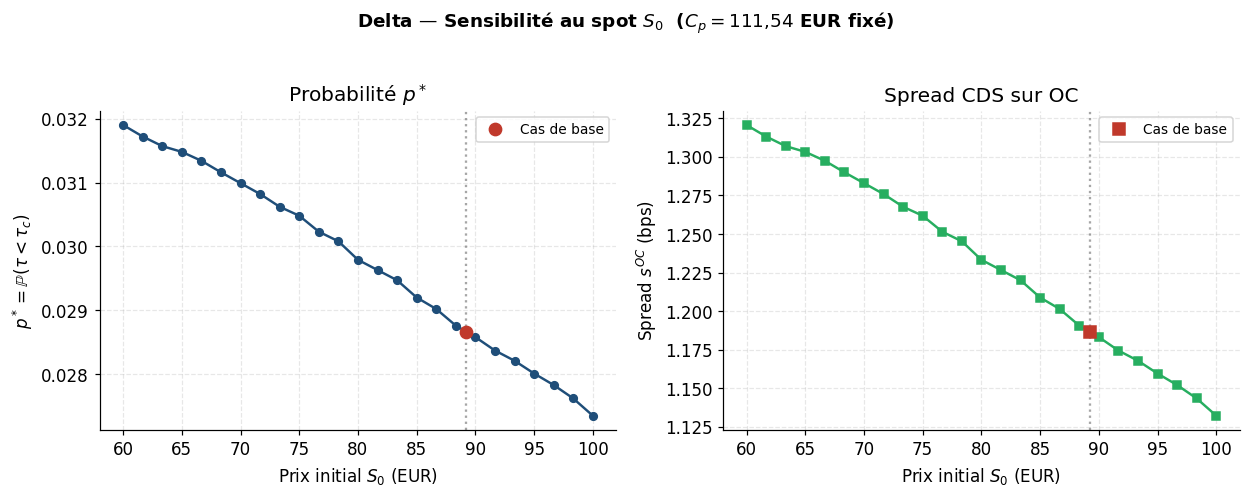

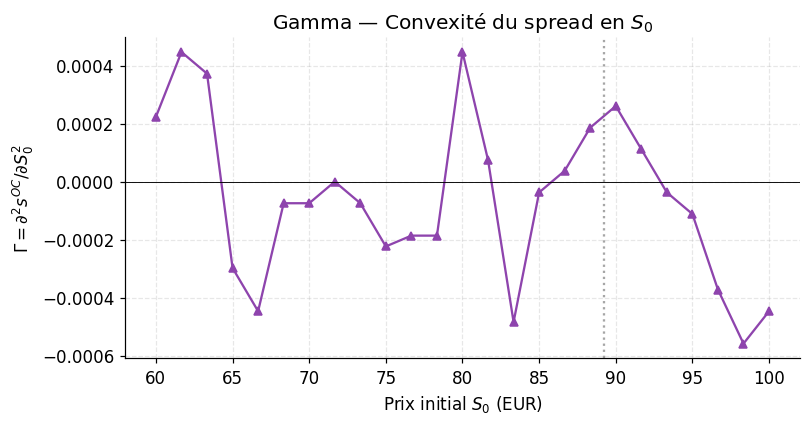

[Vega — sigma]
  530s


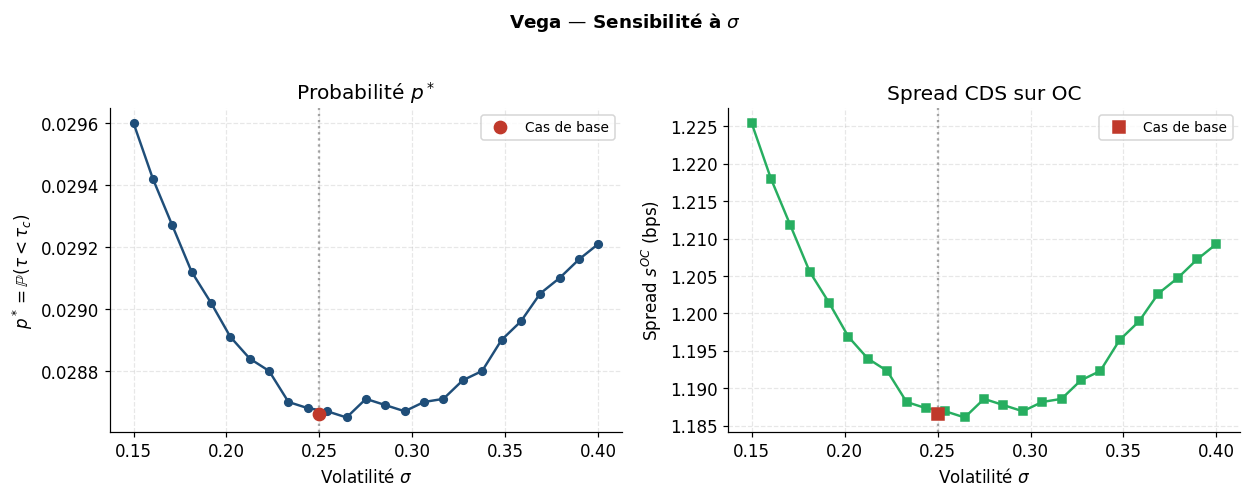

[Rho — r]
  295s


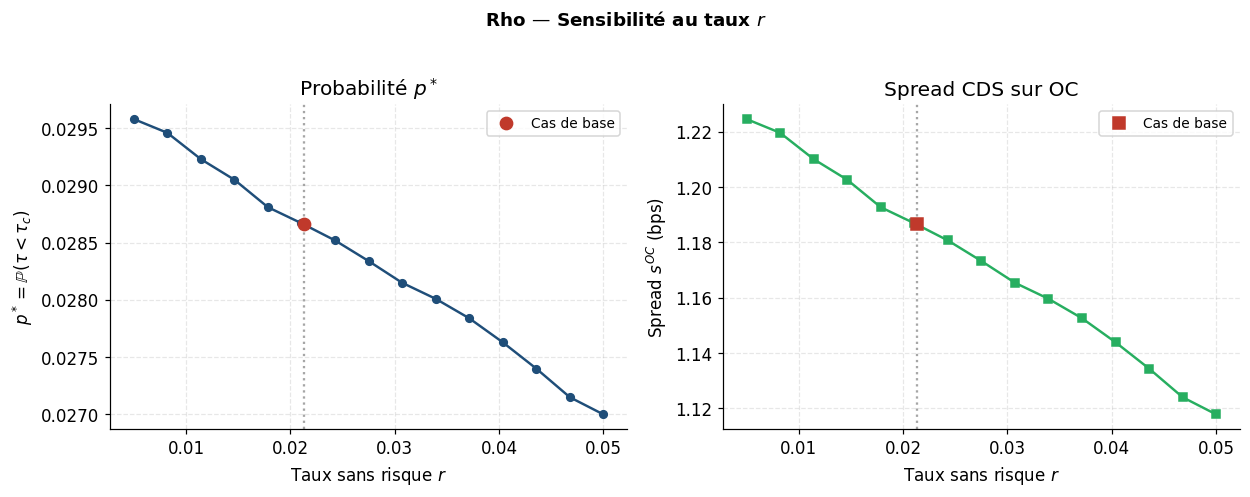

[Theta — T]
  25s


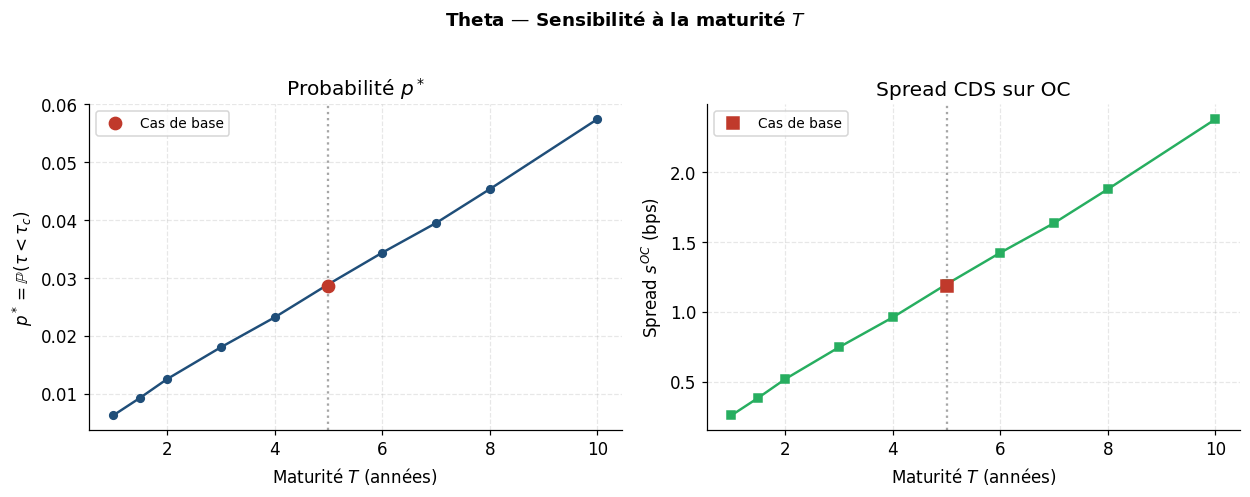

[Lambda — λ]
  190s


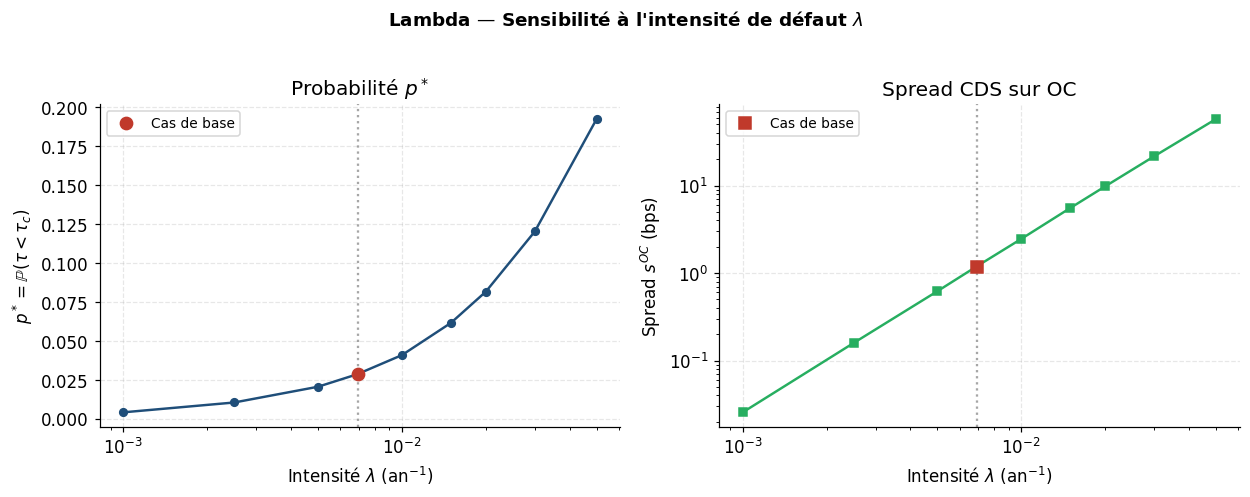

[Kappa — Cp]
  236s


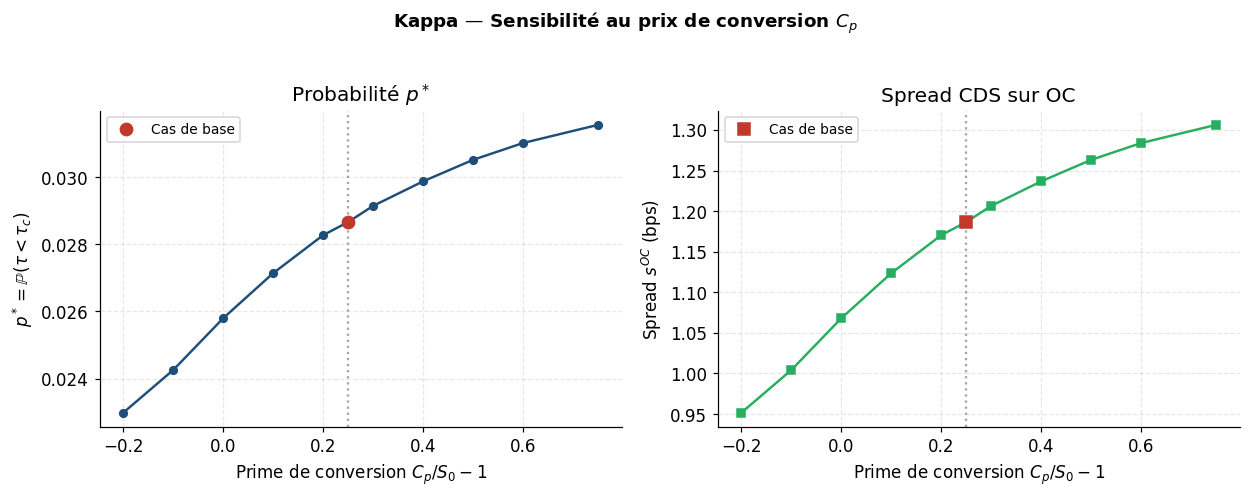


=== ÉLASTICITÉS AU CAS DE BASE ===
  Delta (S0)         : η = -0.365
  Vega (σ)           : η = -0.013
  Rho (r)            : η = -0.034
  Theta (T)          : η = +0.966
  Lambda (λ)         : η = +2.149
  Kappa (Cp)         : η = +0.076


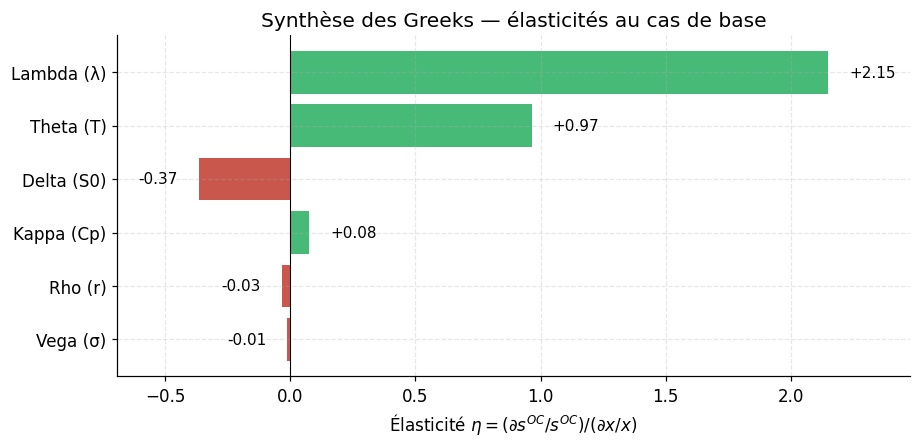

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELLULE 3 — Greeks : Delta, Gamma, Vega, Rho, Theta,
#                      Lambda, Kappa + Tornado
# ============================================================
import time

def plot_greek(df, x_col, x_label, title, fname,
               base_x, base_p, base_s,
               log_x=False, log_y=False):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    axes[0].plot(df[x_col], df["p_star"], "o-",
                 color="#1f4e79", lw=1.6, ms=5)
    axes[0].axvline(base_x, color="grey", ls=":", alpha=0.7)
    axes[0].plot([base_x], [base_p], "o", color="#c0392b",
                 ms=8, label="Cas de base")
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(r"$p^*=\mathbb{P}(\tau<\tau_c)$")
    axes[0].set_title(r"Probabilité $p^*$")
    axes[0].legend(fontsize=9)
    if log_x: axes[0].set_xscale("log")

    axes[1].plot(df[x_col], df["spread_bps"], "s-",
                 color="#27ae60", lw=1.6, ms=5)
    axes[1].axvline(base_x, color="grey", ls=":", alpha=0.7)
    axes[1].plot([base_x], [base_s], "s", color="#c0392b",
                 ms=8, label="Cas de base")
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(r"Spread $s^{OC}$ (bps)")
    axes[1].set_title(r"Spread CDS sur OC")
    axes[1].legend(fontsize=9)
    if log_x: axes[1].set_xscale("log")
    if log_y: axes[1].set_yscale("log")

    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()

def elasticity(x, y, x_base):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    i = np.argmin(np.abs(x - x_base))
    if i == 0 or i == len(x)-1: return None
    return (y[i+1]-y[i-1])/(x[i+1]-x[i-1]) * x_base / y[i]

results = {}  # stocke DataFrames pour le tornado

# ============================================================
# DELTA — sensibilité à S0 ∈ [40, 150] EUR
# Pertinence : S0 détermine la distance au prix de conversion Cp.
# Plus S0 est proche de Cp, plus la conversion est probable,
# plus p* est faible et moins le CDS est utile.
# Plage : couvre stress (-55%) à fort rally (+68%) par rapport au cas de base.
# ============================================================
print("[Delta — S0]"); t=time.time()
S0_grid = np.linspace(60, 100, 25)
res = [(s0, *run(S0=float(s0))) for s0 in S0_grid]
df_S0 = pd.DataFrame(res, columns=["S0","p_star","spread_bps"])
results["S0"] = df_S0
print(f"  {time.time()-t:.0f}s")
plot_greek(df_S0, "S0",
           r"Prix initial $S_0$ (EUR)",
           r"Delta — Sensibilité au spot $S_0$  ($C_p=111{,}54$ EUR fixé)",
           "fig_441_delta",
           base_x=89.23, base_p=ps_base, base_s=sp_base)

# ---- GAMMA — dérivée seconde du spread par rapport à S0 ----
# Mesure la convexité : est-ce que le Delta lui-même accélère ou ralentit ?
spread_arr = df_S0["spread_bps"].values
S0_arr     = df_S0["S0"].values
gamma_arr  = np.gradient(np.gradient(spread_arr, S0_arr), S0_arr)
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(S0_arr, gamma_arr, "^-", color="#8e44ad", lw=1.5, ms=5)
ax.axvline(89.23, color="grey", ls=":", alpha=0.7)
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel(r"Prix initial $S_0$ (EUR)")
ax.set_ylabel(r"$\Gamma = \partial^2 s^{OC}/\partial S_0^2$")
ax.set_title(r"Gamma — Convexité du spread en $S_0$")
plt.tight_layout()
plt.savefig("fig_441_gamma.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# VEGA — sensibilité à σ ∈ [10%, 60%]
# Pertinence : σ gouverne la valeur temps de l'option de conversion.
# Deux effets opposés (valeur temps vs franchissement du seuil)
# dont la compensation est précisément ce qu'on cherche à mesurer.
# Plage : de régime calme (10%) à crise systémique (60%, niveau 2008).
# ============================================================
print("[Vega — sigma]"); t=time.time()
sig_grid = np.linspace(0.15, 0.40, 25)
res = [(sig, *run(sigma=float(sig), n_sim=100_000)) for sig in sig_grid]
df_sig = pd.DataFrame(res, columns=["sigma","p_star","spread_bps"])
results["sigma"] = df_sig
print(f"  {time.time()-t:.0f}s")
plot_greek(df_sig, "sigma",
           r"Volatilité $\sigma$",
           r"Vega — Sensibilité à $\sigma$",
           "fig_442_vega",
           base_x=BASE["sigma"], base_p=ps_base, base_s=sp_base)

# ============================================================
# RHO — sensibilité au taux sans risque r ∈ [0.5%, 5%]
# Pertinence : r intervient dans la dérive du GBM et dans
# l'actualisation de la valeur de continuation. Un r élevé
# rend la conversion plus intéressante plus tôt (drift plus fort),
# ce qui réduit p*. Plage : couvre les régimes de taux récents
# en zone euro (de taux bas post-Covid à normalisation 2023-2024).
# ============================================================
print("[Rho — r]"); t=time.time()
r_grid = np.linspace(0.005, 0.05, 15)
res = [(r, *run(r=float(r), n_sim=100_000)) for r in r_grid]
df_r = pd.DataFrame(res, columns=["r","p_star","spread_bps"])
results["r"] = df_r
print(f"  {time.time()-t:.0f}s")
plot_greek(df_r, "r",
           r"Taux sans risque $r$",
           r"Rho — Sensibilité au taux $r$",
           "fig_443_rho",
           base_x=BASE["r"], base_p=ps_base, base_s=sp_base)

# ============================================================
# THETA — sensibilité à la maturité T ∈ [1, 10] ans
# Pertinence : dans les CDS, le spread dépend de la maturité
# (structure par terme). Ici, T allonge à la fois la fenêtre
# de défaut ET la fenêtre de conversion — l'effet net est non trivial.
# Plage : 1 à 10 ans, couvre les maturités standard du marché CDS.
# D s'adapte automatiquement (discrétisation hebdo pour chaque T).
# ============================================================
print("[Theta — T]"); t=time.time()
T_grid = np.array([1, 1.5, 2, 3, 4, 5, 6, 7, 8, 10])
res = [(T, *run(T=float(T))) for T in T_grid]
df_T = pd.DataFrame(res, columns=["T","p_star","spread_bps"])
results["T"] = df_T
print(f"  {time.time()-t:.0f}s")
plot_greek(df_T, "T",
           r"Maturité $T$ (années)",
           r"Theta — Sensibilité à la maturité $T$",
           "fig_444_theta",
           base_x=5.0, base_p=ps_base, base_s=sp_base)

# ============================================================
# LAMBDA — sensibilité à λ ∈ [10 bp, 500 bp]
# Pertinence : λ est le paramètre crédit central, il entre
# directement dans s^OC = λ(1-R)p* ET dans la distribution
# de τ. Double effet amplificateur → élasticité attendue > 1.
# Plage : AAA (10bp) à CCC/stress (500bp), couvre tout le spectre.
# ============================================================
print("[Lambda — λ]"); t=time.time()
lam_grid = np.array([0.001,0.0025,0.005,0.0069,0.01,0.015,0.02,0.03,0.05])
res = [(lam, *run(lambda_default=float(lam))) for lam in lam_grid]
df_lam = pd.DataFrame(res, columns=["lambda","p_star","spread_bps"])
results["lambda"] = df_lam
print(f"  {time.time()-t:.0f}s")
plot_greek(df_lam, "lambda",
           r"Intensité $\lambda$ (an$^{-1}$)",
           r"Lambda — Sensibilité à l'intensité de défaut $\lambda$",
           "fig_445_lambda",
           base_x=0.006933, base_p=ps_base, base_s=sp_base,
           log_x=True, log_y=True)

# ============================================================
# KAPPA — sensibilité au prix de conversion Cp via la prime π
# π = Cp/S0 - 1 ∈ [-20%, +75%]
# Pertinence : Cp est le seuil de déclenchement de la conversion.
# Plus Cp est élevé (prime haute), plus la conversion est difficile
# → OC se comporte davantage comme une dette pure → p* plus élevé.
# Plage : de conversion ITM dès l'émission (-20%) à OTM profond (+75%).
# ============================================================
print("[Kappa — Cp]"); t=time.time()
prime_grid = np.array([-0.20,-0.10,0,0.10,0.20,0.25,0.30,0.40,0.50,0.60,0.75])
res = []
for pi in prime_grid:
    Cp = (1+pi)*BASE["S0"]; Cr = BASE["N_nominal"]/Cp
    res.append((pi, *run(Cp=Cp, Cr=Cr)))
df_cp = pd.DataFrame(res, columns=["prime","p_star","spread_bps"])
results["prime"] = df_cp
print(f"  {time.time()-t:.0f}s")
plot_greek(df_cp, "prime",
           r"Prime de conversion $C_p/S_0 - 1$",
           r"Kappa — Sensibilité au prix de conversion $C_p$",
           "fig_446_kappa",
           base_x=0.25, base_p=ps_base, base_s=sp_base)

# ============================================================
# ELASTICITÉS + TORNADO (6 paramètres)
# ============================================================
print("\n=== ÉLASTICITÉS AU CAS DE BASE ===")
greek_params = [
    ("Delta (S0)",   results["S0"],     "S0",     89.23),
    ("Vega (σ)",     results["sigma"],  "sigma",  BASE["sigma"]),
    ("Rho (r)",      results["r"],      "r",      BASE["r"]),
    ("Theta (T)",    results["T"],      "T",      5.0),
    ("Lambda (λ)",   results["lambda"], "lambda", 0.006933),
    ("Kappa (Cp)",   results["prime"],  "prime",  0.25),
]
elas_vals, elas_labels = [], []
for label, df_g, x_col, x_base in greek_params:
    e = elasticity(df_g[x_col], df_g["spread_bps"], x_base)
    elas_vals.append(e if e is not None else 0)
    elas_labels.append(label)
    print(f"  {label:<18s} : η = {e:+.3f}" if e else f"  {label:<18s} : η = N/A")

# Tri par valeur absolue croissante (lecture naturelle du tornado)
order = np.argsort(np.abs(elas_vals))
elas_sorted  = [elas_vals[i] for i in order]
labels_sorted = [elas_labels[i] for i in order]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in elas_sorted]
ax.barh(labels_sorted, elas_sorted, color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.7)
xl = ax.get_xlim(); m = (xl[1]-xl[0])*0.03
for i, v in enumerate(elas_sorted):
    ax.text(v+(m if v>=0 else -m), i, f"{v:+.2f}",
            va="center", ha="left" if v>=0 else "right", fontsize=10)
ax.set_xlim(xl[0]-0.2, xl[1]+0.2)
ax.set_xlabel(r"Élasticité $\eta = (\partial s^{OC}/s^{OC})/(\partial x/x)$")
ax.set_title("Synthèse des Greeks — élasticités au cas de base")
plt.tight_layout()
plt.savefig("fig_44_tornado.pdf", bbox_inches="tight")
plt.show()

# --- Téléchargement auto des figures ---
figs = ["fig_42_cours_returns.pdf", "fig_42_estimateurs.pdf",
        "fig_441_delta.pdf", "fig_441_gamma.pdf",
        "fig_442_vega.pdf",  "fig_443_rho.pdf",
        "fig_444_theta.pdf", "fig_445_lambda.pdf",
        "fig_446_kappa.pdf", "fig_44_tornado.pdf"]
for f in figs:
    files.download(f)

# Justification du choix de la profondeur historique à 1 an

Volatilité sur une plage de temps glissante

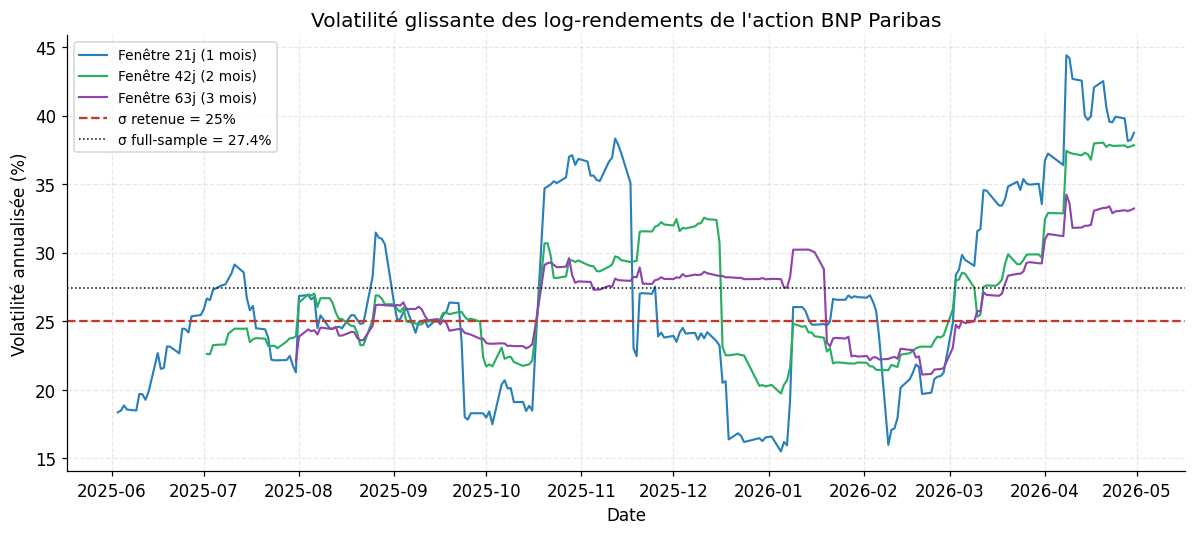


=== Volatilité par trimestre ===
  2025Q2  n= 40  σ = 22.39%
  2025Q3  n= 66  σ = 23.66%
  2025Q4  n= 64  σ = 27.95%
  2026Q1  n= 63  σ = 29.22%
  2026Q2  n= 20  σ = 39.72%


In [ ]:
# ============================================================
# VOLATILITÉ GLISSANTE SUR SOUS-FENÊTRES
# Prérequis : avoir exécuté la cellule 1 (df et ret disponibles)
# ============================================================
from scipy import stats

SIGMA_RETENUE = 0.25   # à ajuster si votre cellule 1 donne autre chose

# --- Paramètre : taille de la fenêtre glissante (en jours) ---
fenetres = {"21j (1 mois)": 21, "42j (2 mois)": 42, "63j (3 mois)": 63}

fig, ax = plt.subplots(figsize=(11, 5))

colors = ["#2980b9", "#27ae60", "#8e44ad"]
for (label, w), col in zip(fenetres.items(), colors):
    # rolling std sur w jours, annualisée
    vol_roll = (
        df["log_ret"]
        .rolling(window=w, min_periods=w)
        .std(ddof=1)
        * np.sqrt(252)
        * 100   # en %
    )
    ax.plot(df["Date"], vol_roll, lw=1.4, color=col, label=f"Fenêtre {label}")

# Valeur retenue
ax.axhline(SIGMA_RETENUE * 100, color="#c0392b", lw=1.5,
           linestyle="--", label=f"σ retenue = {SIGMA_RETENUE*100:.0f}%")

# Vol full-sample (référence)
vol_full = df["log_ret"].std(ddof=1) * np.sqrt(252) * 100
ax.axhline(vol_full, color="black", lw=1, linestyle=":",
           label=f"σ full-sample = {vol_full:.1f}%")

ax.set_ylabel("Volatilité annualisée (%)")
ax.set_xlabel("Date")
ax.set_title("Volatilité glissante des log-rendements de l'action BNP Paribas")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("fig_vol_glissante.pdf", bbox_inches="tight")
plt.show()

# --- Statistiques descriptives par sous-période (trim.) ---
print("\n=== Volatilité par trimestre ===")
df_tmp = df.dropna(subset=["log_ret"]).copy()
df_tmp["trimestre"] = df_tmp["Date"].dt.to_period("Q")
for q, grp in df_tmp.groupby("trimestre"):
    r = grp["log_ret"].values
    sig = r.std(ddof=1) * np.sqrt(252) * 100
    print(f"  {q}  n={len(r):3d}  σ = {sig:.2f}%")

Test de stabilité de la variance (Chow adapté + Levene)

1. TEST F DE FISHER — COUPURE À LA MÉDIANE
  Sous-période 1 : n=126, σ = 26.17%
  Sous-période 2 : n=127, σ = 28.41%
  Statistique F  = 0.8483
  p-value        = 0.3583
  → H0 non rejetée à 5% : pas de preuve de rupture de variance
    (la volatilité est stable, la fenêtre annuelle est cohérente)

2. TEST DE LEVENE — 4 SOUS-PÉRIODES (trimestres)
  2025Q2  n= 40  σ = 22.39%
  2025Q3  n= 66  σ = 23.66%
  2025Q4  n= 64  σ = 27.95%
  2026Q1  n= 63  σ = 29.22%
  2026Q2  n= 20  σ = 39.72%

  Statistique de Levene (Brown-Forsythe) = 1.4738
  p-value                                 = 0.2107
  → H0 non rejetée à 5% : variance homogène entre trimestres

3. BALAYAGE DU POINT DE RUPTURE (supF test)
   Teste toutes les coupures possibles (excl. 15% extrêmes)

  Point de rupture optimal : index 211 → 2026-03-02
  supF = 2.3185  (p-value approx. = 0.0019)
  σ avant : 24.85%
  σ après : 37.84%


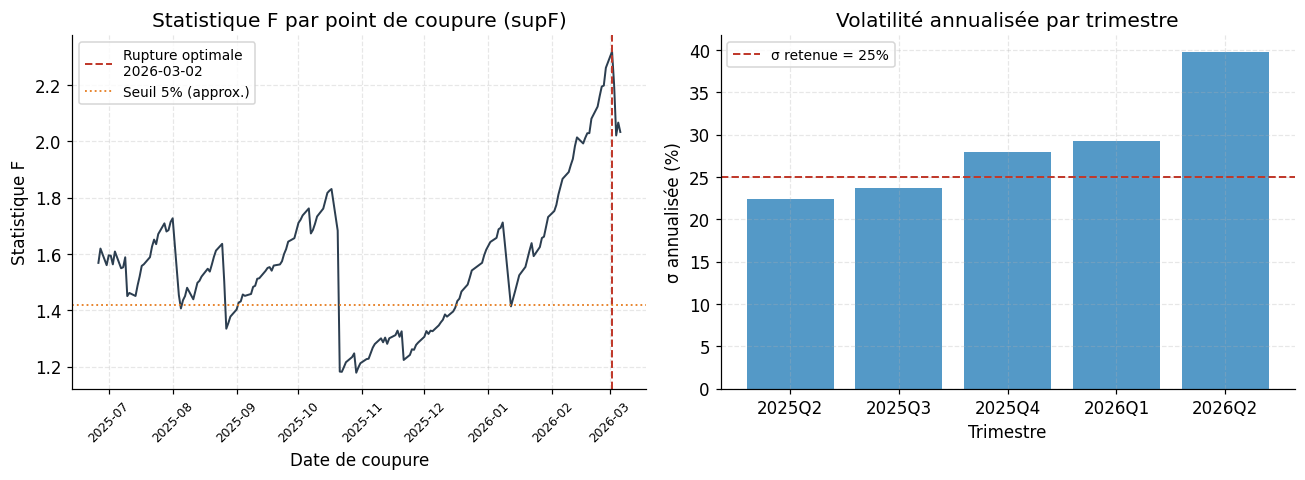


CONCLUSION
  Test F (médiane)     : p = 0.3583  →  stable
  Test Levene (4 trim) : p = 0.2107  →  stable
  supF (rupture opt.)  : p ≈ 0.0019  →  instable

  La variance est homogène sur la période → la fenêtre annuelle
  est justifiée : aucun régime distinct n'est détecté.


In [ ]:
# ============================================================
# TEST DE STABILITÉ DE LA VARIANCE
#
# Deux approches :
#   1. Test F de Fisher  : compare les variances de 2 sous-périodes
#      (équivalent au test de Chow sur une constante)
#   2. Test de Levene    : généralise à k sous-périodes,
#      robuste à la non-normalité (kurtosis élevée ici)
#   3. Balayage du point de rupture (supF) : cherche le point
#      de rupture qui maximise la statistique de test
# ============================================================
from scipy import stats

ret_clean = df["log_ret"].dropna().values
n = len(ret_clean)
dates_clean = df["Date"].dropna().iloc[1:].reset_index(drop=True)  # dates des log-returns

# ---- 1. TEST F (comparaison 2 sous-périodes : première vs seconde moitié) ----
print("=" * 60)
print("1. TEST F DE FISHER — COUPURE À LA MÉDIANE")
print("=" * 60)

mid = n // 2
r1, r2 = ret_clean[:mid], ret_clean[mid:]
s1, s2 = r1.std(ddof=1), r2.std(ddof=1)
n1, n2 = len(r1), len(r2)

F_stat = (s1**2) / (s2**2)   # si s1 > s2, sinon inverser
df1, df2 = n1 - 1, n2 - 1
# p-value bilatérale
p_val_F = 2 * min(stats.f.cdf(F_stat, df1, df2),
                  1 - stats.f.cdf(F_stat, df1, df2))

print(f"  Sous-période 1 : n={n1}, σ = {s1*np.sqrt(252)*100:.2f}%")
print(f"  Sous-période 2 : n={n2}, σ = {s2*np.sqrt(252)*100:.2f}%")
print(f"  Statistique F  = {F_stat:.4f}")
print(f"  p-value        = {p_val_F:.4f}")
if p_val_F < 0.05:
    print("  → H0 rejetée à 5% : les variances sont significativement différentes")
    print("    (la volatilité n'est PAS stable sur toute la période)")
else:
    print("  → H0 non rejetée à 5% : pas de preuve de rupture de variance")
    print("    (la volatilité est stable, la fenêtre annuelle est cohérente)")


# ---- 2. TEST DE LEVENE — k = 4 TRIMESTRES ----
print("\n" + "=" * 60)
print("2. TEST DE LEVENE — 4 SOUS-PÉRIODES (trimestres)")
print("=" * 60)

df_tmp = df.dropna(subset=["log_ret"]).copy()
df_tmp["trimestre"] = df_tmp["Date"].dt.to_period("Q")
groupes = [grp["log_ret"].values for _, grp in df_tmp.groupby("trimestre")]

# Afficher les σ par trimestre
for (q, _), g in zip(df_tmp.groupby("trimestre"), groupes):
    print(f"  {q}  n={len(g):3d}  σ = {g.std(ddof=1)*np.sqrt(252)*100:.2f}%")

lev_stat, lev_p = stats.levene(*groupes, center="median")  # center=median = Brown-Forsythe, robuste
print(f"\n  Statistique de Levene (Brown-Forsythe) = {lev_stat:.4f}")
print(f"  p-value                                 = {lev_p:.4f}")
if lev_p < 0.05:
    print("  → H0 rejetée à 5% : variance hétérogène entre trimestres")
else:
    print("  → H0 non rejetée à 5% : variance homogène entre trimestres")


# ---- 3. BALAYAGE DU POINT DE RUPTURE (supF) ----
print("\n" + "=" * 60)
print("3. BALAYAGE DU POINT DE RUPTURE (supF test)")
print("=" * 60)
print("   Teste toutes les coupures possibles (excl. 15% extrêmes)")

trim = int(0.15 * n)   # exclure les 15% de chaque côté
F_vals, break_idx = [], []

for tau in range(trim, n - trim):
    r_a = ret_clean[:tau]
    r_b = ret_clean[tau:]
    s_a, s_b = r_a.std(ddof=1), r_b.std(ddof=1)
    if s_b == 0: continue
    F_t = (s_a**2) / (s_b**2)
    F_t = max(F_t, 1/F_t)   # toujours >= 1
    F_vals.append(F_t)
    break_idx.append(tau)

best_tau = break_idx[np.argmax(F_vals)]
best_F   = max(F_vals)
best_date = dates_clean.iloc[best_tau].date()

# p-value approximative au point de rupture optimal
p_approx = 2 * (1 - stats.f.cdf(best_F, best_tau-1, n-best_tau-1))
print(f"\n  Point de rupture optimal : index {best_tau} → {best_date}")
print(f"  supF = {best_F:.4f}  (p-value approx. = {p_approx:.4f})")
print(f"  σ avant : {ret_clean[:best_tau].std(ddof=1)*np.sqrt(252)*100:.2f}%")
print(f"  σ après : {ret_clean[best_tau:].std(ddof=1)*np.sqrt(252)*100:.2f}%")

# ---- Graphe du balayage ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Courbe supF
axes[0].plot(dates_clean.iloc[break_idx], F_vals, color="#2c3e50", lw=1.3)
axes[0].axvline(dates_clean.iloc[best_tau], color="#c0392b",
                linestyle="--", lw=1.3, label=f"Rupture optimale\n{best_date}")
axes[0].axhline(stats.f.ppf(0.975, n//2, n//2), color="#e67e22",
                linestyle=":", lw=1.2, label="Seuil 5% (approx.)")
axes[0].set_title("Statistique F par point de coupure (supF)")
axes[0].set_ylabel("Statistique F")
axes[0].set_xlabel("Date de coupure")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', labelsize=8, rotation=45)
# Volatilité par trimestre (barres)
vols_trim = [g.std(ddof=1)*np.sqrt(252)*100 for g in groupes]
labels_trim = [str(q) for q, _ in df_tmp.groupby("trimestre")]
axes[1].bar(labels_trim, vols_trim, color="#2980b9", alpha=0.8)
axes[1].axhline(SIGMA_RETENUE * 100, color="#c0392b", linestyle="--",
                lw=1.3, label=f"σ retenue = {SIGMA_RETENUE*100:.0f}%")
axes[1].set_title("Volatilité annualisée par trimestre")
axes[1].set_ylabel("σ annualisée (%)")
axes[1].set_xlabel("Trimestre")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_stabilite_variance.pdf", bbox_inches="tight")
plt.show()

# ---- Conclusion synthétique ----
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print(f"  Test F (médiane)     : p = {p_val_F:.4f}  →  "
      + ("instable" if p_val_F < 0.05 else "stable"))
print(f"  Test Levene (4 trim) : p = {lev_p:.4f}  →  "
      + ("instable" if lev_p < 0.05 else "stable"))
print(f"  supF (rupture opt.)  : p ≈ {p_approx:.4f}  →  "
      + ("instable" if p_approx < 0.05 else "stable"))
print()
if max(p_val_F, lev_p) > 0.05:
    print("  La variance est homogène sur la période → la fenêtre annuelle")
    print("  est justifiée : aucun régime distinct n'est détecté.")
else:
    print("  La variance est hétérogène → la fenêtre annuelle intègre")
    print("  plusieurs régimes. Envisager une fenêtre plus courte")
    print(f"  (après {best_date}) ou un estimateur EWMA.")